In [ ]:
import pyoccam

# Initialize
manager = pyoccam.VBMManager()
manager.init_from_command_line(["occam", "dementia05.txt"])

# Search - Report class formats everything
search_report = manager.generate_search_report("loopless-up", 3, 3)
print(search_report)  # ALL formatting done by C++!

# Get best model (tracked during search, no parsing)
best = manager.get_best_model_by_bic()
if best:
    print(f"Best: {best.get_name()}")

# Fit report - Report class handles contingency tables, confusion matrices, etc.
fit_report = manager.generate_fit_report("IV:ApSxZ")
print(fit_report)  # ALL formatting done by C++!

In [2]:
"""
Debug test script to isolate where pyoccam is hanging
Run this step by step to find the problem
"""

import pyoccam
import sys

print("="*60)
print("PYOCCAM DEBUG TEST")
print("="*60)

# Step 1: Test module import
print("\n1. Testing module import...")
print(f"   pyoccam version: {pyoccam.__version__}")
print("   Import successful!")

# Step 2: Test VBMManager creation
print("\n2. Creating VBMManager...")
try:
    manager = pyoccam.VBMManager()
    print("   Manager created successfully!")
except Exception as e:
    print(f"   ERROR: {e}")
    sys.exit(1)

# Step 3: Test initialization
print("\n3. Initializing with dementia05.txt...")
print("   Calling init_from_command_line...")
try:
    success = manager.init_from_command_line(["occam", "dementia05.txt"])
    print(f"   Initialization returned: {success}")
    if not success:
        print("   ERROR: Initialization failed")
        sys.exit(1)
except Exception as e:
    print(f"   ERROR: {e}")
    sys.exit(1)

# Step 4: Test getting sample size
print("\n4. Testing basic data access...")
try:
    sample_size = manager.get_sample_size()
    print(f"   Sample size: {sample_size}")
except Exception as e:
    print(f"   ERROR: {e}")

# Step 5: Test getting reference models
print("\n5. Testing reference model access...")
try:
    bottom_ref = manager.get_bottom_ref_model()
    if bottom_ref:
        print(f"   Bottom ref model: {bottom_ref.get_name()}")
    else:
        print("   No bottom ref model")
except Exception as e:
    print(f"   ERROR: {e}")

# Step 6: Test MINIMAL search (1 level, 1 width)
print("\n6. Testing MINIMAL search (1 level, 1 width)...")
print("   This is where it might hang...")
print("   Calling generate_search_report...")
try:
    report = manager.generate_search_report(
        search_type="full-up",
        levels=3,  # Just 1 level!
        width=3    # Just 1 model!
    )
    print(f"   Report generated! Length: {len(report)} chars")
    print("\n   First 500 chars of report:")
    print(report[:500])
except KeyboardInterrupt:
    print("\n   INTERRUPTED: Search was hanging")
    sys.exit(1)
except Exception as e:
    print(f"   ERROR: {e}")

# Step 7: Check report output for best model
print("\n7. Checking report for best model identification...")
try:
    # The Report class identifies best models at the bottom of the output
    if "Best Model" in report:
        print("   Best model identification found in report!")
        # Extract the lines containing "Best Model"
        for line in report.split('\n'):
            if "Best Model" in line:
                print(f"   {line}")
    else:
        print("   No best model identification in report")
except Exception as e:
    print(f"   ERROR: {e}")

print("\n" + "="*60)
print("DEBUG TEST COMPLETE")
print("="*60)

PYOCCAM DEBUG TEST

1. Testing module import...
   pyoccam version: 3.4.0
   Import successful!

2. Creating VBMManager...
   Manager created successfully!

3. Initializing with dementia05.txt...
   Calling init_from_command_line...
   Initialization returned: True

4. Testing basic data access...
   Sample size: 424.0

5. Testing reference model access...
   Bottom ref model: IV:Z

6. Testing MINIMAL search (1 level, 1 width)...
   This is where it might hang...
   Calling generate_search_report...
   Report generated! Length: 2549 chars

   First 500 chars of report:
  ID   MODEL        
 115   IV:ApZ:BZ:PZ 
 114   IV:ApZ:BZ    
 113   IV:ApZ:NZ:PZ 
 112   IV:ApZ:NZ    
 111   IV:ApZ:HZ:PZ 
 110   IV:ApZ:PZ    
 109   IV:ApZ       
 108   IV:BZ:CZ:PZ  
 107   IV:CZ:NZ:PZ  
 106   IV:EdZ:BZ:PZ 
 105   IV:BZ:CZ     
 104   IV:CZ:NZ     
 103   IV:EdZ:NZ:PZ 
 102   IV:EdZ:BZ    
 101   IV:BZ:KZ:PZ  
 100   IV:BZ:KZ     
  99   IV:KZ:NZ:PZ  
  98   IV:EdZ:NZ    
  97   IV:KZ:NZ     
  96

In [ ]:
"""
Simple working example for pyoccam
Uses the truly simplified bindings where Report class does everything
"""

import pyoccam

print("="*60)
print("PYOCCAM SIMPLE EXAMPLE")
print("="*60)

# Initialize
manager = pyoccam.VBMManager()
success = manager.init_from_command_line(["occam", "dementia05.txt"])

if not success:
    print("Failed to initialize")
    exit(1)

print(f"\nInitialized successfully")
print(f"Sample size: {manager.get_sample_size()}")

# Get variable info
var_list = manager.get_variable_list()
if var_list:
    print(f"Variables: {var_list.get_var_count()}")
    print(f"Directed: {var_list.is_directed()}")

# Generate search report
# Start with small values to avoid hanging
print("\n" + "="*60)
print("SEARCH REPORT (2 levels, 2 width)")
print("="*60)

report = manager.generate_search_report(
    search_type="loopless-up",
    levels=2,  # Just 2 levels to avoid hanging
    width=2    # Just 2 models per level
)

print(report)

# The best models are identified at the bottom of the report
# Look for lines like:
# Best Model(s) by dBIC: 19 IV:ApZ
# Best Model(s) by dAIC: 19 IV:ApZ

# Generate a fit report for a specific model
print("\n" + "="*60)
print("FIT REPORT FOR IV:ApZ")
print("="*60)

fit_report = manager.generate_fit_report("IV:ApZ")
print(fit_report)

print("\n" + "="*60)
print("EXAMPLE COMPLETE")
print("="*60)

In [1]:
"""
Minimal working example - generates report files without hanging
"""

import pyoccam
import os

print("="*60)
print("PYOCCAM - MINIMAL REPORT GENERATION")
print("="*60)

# Initialize
manager = pyoccam.VBMManager()
success = manager.init_from_command_line(["occam", "dementia05.txt"])

if not success:
    print("Failed to initialize")
    exit(1)

print(f"✅ Initialized successfully")
print(f"Sample size: {manager.get_sample_size()}")

# Generate search report (minimal - won't hang)
print("\n" + "="*60)
print("GENERATING SEARCH REPORT")
print("="*60)

print("Creating search_report.txt...")
result = manager.generate_search_report("loopless-up", 3, 3)
print(result.split('\n')[0])  # Just show the file info

# Check if file exists
if os.path.exists("search_report.txt"):
    size = os.path.getsize("search_report.txt")
    print(f"✅ search_report.txt created ({size} bytes)")

    # Show first few lines
    with open("search_report.txt", "r") as f:
        lines = f.readlines()
        print("\nFirst 10 lines of search report:")
        for line in lines[:10]:
            print(line.rstrip())

# Generate fit report for hardcoded model
print("\n" + "="*60)
print("GENERATING FIT REPORT FOR IV:ApSxAZ")
print("="*60)

print("Creating fit_IV_ApSxAZ.txt...")
fit_result = manager.generate_fit_report("IV:ApSxAZ")
print(fit_result.split('\n')[0])  # Just show the file info

# Check if file exists
fit_file = "fit_IV_ApSxAZ.txt"
if os.path.exists(fit_file):
    size = os.path.getsize(fit_file)
    print(f"✅ {fit_file} created ({size} bytes)")

    # Show first few lines
    with open(fit_file, "r") as f:
        lines = f.readlines()
        print("\nFirst 10 lines of fit report:")
        for line in lines[:10]:
            print(line.rstrip())

print("\n" + "="*60)
print("SUCCESS - REPORT FILES GENERATED!")
print("="*60)
print("\n📁 Files created:")
print("  • search_report.txt - Search results")
print("  • fit_IV_ApSxAZ.txt - Fit analysis for your model")
print("\nYou can manually review search_report.txt to find the best model")

PYOCCAM - MINIMAL REPORT GENERATION
✅ Initialized successfully
Sample size: 424.0

GENERATING SEARCH REPORT
Creating search_report.txt...
  ID   MODEL               Level         H        dDF        dLR     Alpha         Inf   %dH(DV)       dAIC       dBIC
✅ search_report.txt created (168 bytes)

First 10 lines of search report:
  ID   MODEL
   3   IV:Z
   2   IV:ApZ
   1   IV:SxZ
  ID   MODEL


Best Model(s) by dBIC:
   2   IV:ApZ
Best Model(s) by dAIC:

GENERATING FIT REPORT FOR IV:ApSxAZ
Creating fit_IV_ApSxAZ.txt...
    Model,IV:ApSxAZ (Directed System)
✅ fit_IV_ApSxAZ.txt created (314 bytes)

First 10 lines of fit report:
  ID   MODEL
   1   IV:ApSxAZ
  ID   MODEL


Best Model(s) by dBIC:
   1   IV:ApSxAZ
Best Model(s) by dAIC:
   1   IV:ApSxAZ


SUCCESS - REPORT FILES GENERATED!

📁 Files created:
  • search_report.txt - Search results
  • fit_IV_ApSxAZ.txt - Fit analysis for your model

You can manually review search_report.txt to find the best model


In [1]:
#!/usr/bin/env python
"""
Test script for OCCAM Python bindings
Generates search report and fit report for model IV:ApSxAZ
"""

import pyoccam
import sys
import time

def main():
    print("=" * 80)
    print("OCCAM Python Bindings Test")
    print("=" * 80)

    # Configuration
    DATA_FILE = "dementia05.txt"  # Change this to your data file
    SEARCH_TYPE = "loopless-up"   # Use correct search type with "-up" suffix
    SEARCH_LEVELS = 3              # Keep low for testing (3-5 is reasonable)
    SEARCH_WIDTH = 3               # Width of search beam
    TARGET_MODEL = "IV:ApSxAZ"     # Model to fit

    # Initialize manager
    print("\n1. Initializing OCCAM...")
    manager = pyoccam.VBMManager()

    # Load data
    args = ["occam", DATA_FILE]
    success = manager.init_from_command_line(args)

    if not success:
        print(f"❌ Failed to initialize with data file: {DATA_FILE}")
        print("Please ensure the data file exists in the current directory")
        return 1

    print(f"✅ Successfully loaded data from {DATA_FILE}")

    # Get basic information
    print(f"\nSample size: {manager.get_sample_size()}")
    print(f"Has test data: {manager.has_test_data()}")

    # Display variables
    variables = manager.get_variable_list()
    print(f"Variables ({len(variables)}): {', '.join(variables)}")

    # Configure report settings
    print("\n2. Configuring report settings...")
    manager.set_report_separator(pyoccam.SPACESEP)
    manager.set_ref_model("bottom")
    manager.set_report_variables("ID$I, Model, Level$I, h, ddf, dLR, Alpha, Inf, %dH(DV), dAIC, dBIC")
    print("✅ Report settings configured")

    # Generate search report
    print(f"\n3. Generating {SEARCH_TYPE} search report...")
    print(f"   Levels: {SEARCH_LEVELS}, Width: {SEARCH_WIDTH}")

    start_time = time.time()
    search_report = manager.generate_search_report(
        search_type=SEARCH_TYPE,
        levels=SEARCH_LEVELS,
        width=SEARCH_WIDTH,
        include_test_data=False
    )
    search_time = time.time() - start_time

    print(f"✅ Search completed in {search_time:.2f} seconds")

    # Display search report
    print("\n" + "=" * 80)
    print("SEARCH REPORT")
    print("=" * 80)
    print(search_report)

    # Save search report to file
    with open("search_report.txt", "w") as f:
        f.write(search_report)
    print("\n✅ Search report saved to 'search_report.txt'")

    # Get best models
    print("\n4. Best models from search:")
    best_bic = manager.get_best_model_by_bic()
    best_aic = manager.get_best_model_by_aic()
    best_info = manager.get_best_model_by_information()

    if best_bic:
        print(f"   Best BIC model: {best_bic}")
    if best_aic:
        print(f"   Best AIC model: {best_aic}")
    if best_info:
        print(f"   Best Information model: {best_info}")

    # Generate fit report for target model
    print(f"\n5. Generating fit report for model: {TARGET_MODEL}")

    start_time = time.time()
    fit_report = manager.generate_fit_report(TARGET_MODEL)
    fit_time = time.time() - start_time

    print(f"✅ Fit report generated in {fit_time:.2f} seconds")

    # Display fit report
    print("\n" + "=" * 80)
    print(f"FIT REPORT FOR MODEL: {TARGET_MODEL}")
    print("=" * 80)
    print(fit_report)

    # Save fit report to file
    with open("fit_report.txt", "w") as f:
        f.write(fit_report)
    print("\n✅ Fit report saved to 'fit_report.txt'")

    # Get model statistics
    print(f"\n6. Model statistics for {TARGET_MODEL}:")
    model_stats = manager.get_model_statistics(TARGET_MODEL)

    print(f"   H (entropy): {model_stats.h:.4f}")
    print(f"   Information: {model_stats.information:.4f}")
    print(f"   Alpha: {model_stats.alpha:.4f}")
    print(f"   BIC: {model_stats.bic:.4f}")
    print(f"   AIC: {model_stats.aic:.4f}")
    print(f"   dBIC: {model_stats.dbic:.4f}")
    print(f"   dAIC: {model_stats.daic:.4f}")
    print(f"   LR: {model_stats.lr:.4f}")
    print(f"   DF: {model_stats.df:.0f}")
    print(f"   % Correct: {model_stats.pct_correct_data:.2f}%")

    # Try to get confusion matrix (placeholder for now)
    print(f"\n7. Confusion matrix for {TARGET_MODEL} (target state: 0):")
    cm = manager.get_confusion_matrix(TARGET_MODEL, "0")

    if cm:
        print(f"   True Positives: {cm['tp']}")
        print(f"   True Negatives: {cm['tn']}")
        print(f"   False Positives: {cm['fp']}")
        print(f"   False Negatives: {cm['fn']}")
        if cm['accuracy'] > 0:
            print(f"   Accuracy: {cm['accuracy']:.3f}")
            print(f"   Sensitivity: {cm['sensitivity']:.3f}")
            print(f"   Specificity: {cm['specificity']:.3f}")

    print("\n" + "=" * 80)
    print("✅ Test completed successfully!")
    print("=" * 80)

    return 0

if __name__ == "__main__":
    try:
        sys.exit(main())
    except KeyboardInterrupt:
        print("\n\n⚠️ Test interrupted by user")
        sys.exit(1)
    except Exception as e:
        print(f"\n❌ Error: {e}")
        import traceback
        traceback.print_exc()
        sys.exit(1)

OCCAM Python Bindings Test

1. Initializing OCCAM...
✅ Successfully loaded data from dementia05.txt

Sample size: 424.0
Has test data: False
Variables (19): Ap, Sx, Ed, Ag, A, B, C, D, E, F, G, H, J, K, L, M, N, P, Z

2. Configuring report settings...
✅ Report settings configured

3. Generating loopless-up search report...
   Levels: 3, Width: 3
✅ Search completed in 0.07 seconds

SEARCH REPORT
  ID   MODEL                 ID          Model          Level              H            dDF            dLR          Alpha            Inf        %dH(DV)           dAIC           dBIC
 112   IV:ApJPZ                                             3         9.6008             31                        0.0000                                     -11.9549       113.5868
 111   IV:ApBPZ                                             3         9.6038             31                        0.0000                                     -10.2210       115.3207
 110   IV:ApNPZ                                         

SystemExit: 0

C:\Users\bjpd\Anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3452: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [3]:
%tb

SystemExit: 0

In [2]:
#!/usr/bin/env python
"""
Verification script to compare pyoccam output with server output
Helps identify any discrepancies in the generated reports
"""

import pyoccam
import re
import sys
from collections import defaultdict

def parse_search_report(report_text):
    """Parse a search report into structured data"""
    models = []
    lines = report_text.strip().split('\n')

    # Find the data rows (skip headers and empty lines)
    data_started = False
    for line in lines:
        # Skip empty lines and headers
        if not line.strip() or 'MODEL' in line or '---' in line:
            continue

        # Try to parse as data row
        parts = line.split()
        if len(parts) >= 11 and parts[0].isdigit():
            try:
                model_info = {
                    'id': int(parts[0]),
                    'name': parts[1],
                    'level': int(parts[2]) if parts[2].isdigit() else 0,
                    'h': float(parts[3]),
                    'ddf': int(parts[4]) if parts[4].isdigit() else 0,
                    'dlr': float(parts[5]) if len(parts) > 5 else 0.0,
                    'alpha': float(parts[6]) if len(parts) > 6 else 0.0,
                    'inf': float(parts[7]) if len(parts) > 7 else 0.0,
                    'pct_dh': float(parts[8]) if len(parts) > 8 else 0.0,
                    'daic': float(parts[9]) if len(parts) > 9 else 0.0,
                    'dbic': float(parts[10]) if len(parts) > 10 else 0.0,
                }
                models.append(model_info)
            except (ValueError, IndexError):
                continue

    return models

def find_duplicates(models):
    """Find duplicate models in the report"""
    model_counts = defaultdict(list)
    for model in models:
        key = model['name']
        model_counts[key].append(model['id'])

    duplicates = {name: ids for name, ids in model_counts.items() if len(ids) > 1}
    return duplicates

def compare_models(model1, model2, tolerance=0.0001):
    """Compare two model dictionaries for equality"""
    if model1['name'] != model2['name']:
        return False

    # Compare numeric fields with tolerance
    numeric_fields = ['h', 'alpha', 'inf', 'daic', 'dbic']
    for field in numeric_fields:
        if abs(model1.get(field, 0) - model2.get(field, 0)) > tolerance:
            return False

    return True

def main():
    print("=" * 80)
    print("OCCAM Output Verification")
    print("=" * 80)

    # Configuration
    DATA_FILE = "dementia05.txt"
    SEARCH_TYPE = "full-up"  # Match your example
    SEARCH_LEVELS = 7
    SEARCH_WIDTH = 3

    # Initialize and run search
    print(f"\n1. Running {SEARCH_TYPE} search...")
    manager = pyoccam.VBMManager()

    success = manager.init_from_command_line(["occam", DATA_FILE])
    if not success:
        print(f"Failed to load {DATA_FILE}")
        return 1

    # Configure
    manager.set_report_separator(pyoccam.SPACESEP)
    manager.set_ref_model("bottom")

    # Generate report
    search_report = manager.generate_search_report(
        SEARCH_TYPE,
        SEARCH_LEVELS,
        SEARCH_WIDTH,
        False
    )

    # Parse the report
    print("\n2. Analyzing search report...")
    models = parse_search_report(search_report)
    print(f"   Total models found: {len(models)}")

    # Check for duplicates
    duplicates = find_duplicates(models)
    if duplicates:
        print(f"\n⚠️  Duplicate models found:")
        for name, ids in duplicates.items():
            print(f"   {name}: IDs {ids}")
    else:
        print("✅ No duplicate models found")

    # Find best models
    print("\n3. Best models analysis:")
    if models:
        # Sort by different criteria
        best_bic = max(models, key=lambda x: x['dbic'])
        best_aic = max(models, key=lambda x: x['daic'])
        best_inf = max(models, key=lambda x: x['inf'])

        print(f"   Best by dBIC: {best_bic['name']} (dBIC={best_bic['dbic']:.4f})")
        print(f"   Best by dAIC: {best_aic['name']} (dAIC={best_aic['daic']:.4f})")
        print(f"   Best by Inf:  {best_inf['name']} (Inf={best_inf['inf']:.4f})")

    # Check model distribution by level
    print("\n4. Model distribution by level:")
    level_counts = defaultdict(int)
    for model in models:
        level_counts[model['level']] += 1

    for level in sorted(level_counts.keys()):
        print(f"   Level {level}: {level_counts[level]} models")

    # Verify specific models
    print("\n5. Checking specific models:")
    target_models = ['IV:ApZ', 'IV:ApSxAZ', 'IV:ApZ:BZ', 'IV:ApZ:NZ:PZ']

    for target in target_models:
        found = [m for m in models if m['name'] == target]
        if found:
            m = found[0]
            print(f"   ✅ {target}: H={m['h']:.4f}, dBIC={m['dbic']:.4f}, Level={m['level']}")
        else:
            print(f"   ❌ {target}: Not found in search results")

    # Save cleaned report
    print("\n6. Saving verified report...")
    with open("verified_search_report.txt", "w") as f:
        f.write("VERIFIED SEARCH REPORT\n")
        f.write("=" * 80 + "\n")
        f.write(f"Search Type: {SEARCH_TYPE}\n")
        f.write(f"Levels: {SEARCH_LEVELS}, Width: {SEARCH_WIDTH}\n")
        f.write(f"Total Models: {len(models)}\n")
        f.write(f"Duplicates: {len(duplicates)}\n")
        f.write("=" * 80 + "\n\n")
        f.write(search_report)

    print("✅ Verified report saved to 'verified_search_report.txt'")

    # Final summary
    print("\n" + "=" * 80)
    if not duplicates:
        print("✅ VERIFICATION PASSED - No issues found")
    else:
        print("⚠️  VERIFICATION WARNING - Duplicates need to be addressed")
    print("=" * 80)

    return 0

if __name__ == "__main__":
    try:
        sys.exit(main())
    except Exception as e:
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()
        sys.exit(1)

OCCAM Output Verification

1. Running full-up search...

2. Analyzing search report...
   Total models found: 306
✅ No duplicate models found

3. Best models analysis:
   Best by dBIC: IV:BJZ:BNZ:BPZ (dBIC=196.6925)
   Best by dAIC: IV:BHZ:BNZ:NPZ (dAIC=39.3396)
   Best by Inf:  IV:ApZ:BNZ:BPZ:JZ (Inf=0.1423)

4. Model distribution by level:
   Level 0: 1 models
   Level 1: 18 models
   Level 2: 48 models
   Level 3: 48 models
   Level 4: 48 models
   Level 5: 49 models
   Level 6: 46 models
   Level 7: 48 models

5. Checking specific models:
   ✅ IV:ApZ: H=9.6396, dBIC=-46.1155, Level=1
   ❌ IV:ApSxAZ: Not found in search results
   ✅ IV:ApZ:BZ: H=9.6280, dBIC=-34.7805, Level=2
   ✅ IV:ApZ:NZ:PZ: H=9.6302, dBIC=-15.3327, Level=3

6. Saving verified report...
✅ Verified report saved to 'verified_search_report.txt'

✅ VERIFICATION PASSED - No issues found


SystemExit: 0

C:\Users\bjpd\Anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3452: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [3]:
#!/usr/bin/env python3
"""
Test script to verify the fixed pyoccam implementation
This should generate complex models and track best models correctly
"""

import pyoccam
import time

def main():
    print("=" * 70)
    print("TESTING FIXED PYOCCAM IMPLEMENTATION")
    print("=" * 70)

    # Initialize
    manager = pyoccam.VBMManager()

    # Load data
    print("\n1. Loading data...")
    if not manager.init_from_command_line(["occam", "dementia05.txt"]):
        print("ERROR: Could not load data file")
        return False
    print("   ✓ Data loaded successfully")

    # Get basic info
    sample_size = manager.get_sample_size()
    variables = manager.get_variable_list()
    print(f"   Sample size: {sample_size}")
    print(f"   Variables: {', '.join(variables)}")

    # Configure
    print("\n2. Configuring...")
    manager.set_report_separator(pyoccam.SPACESEP)
    manager.set_ref_model("bottom")
    print("   ✓ Configuration complete")

    # Run search - use FULL parameters to match server
    print("\n3. Running search (this should generate complex models)...")
    print("   Search type: full-up")
    print("   Levels: 7")
    print("   Width: 3")

    start_time = time.time()
    search_report = manager.generate_search_report(
        search_type="full-up",  # Use full-up to get complex models
        levels=7,                # Full 7 levels like server
        width=3,                 # Width 3 like server
        include_test_data=False
    )
    elapsed = time.time() - start_time

    print(f"   ✓ Search completed in {elapsed:.2f} seconds")

    # Check for complex models
    print("\n4. Checking for complex models...")
    complex_models = []
    for line in search_report.split('\n'):
        if 'IV:' in line and ':' in line[3:]:  # Multi-component model
            parts = line.split()
            if len(parts) >= 2:
                model_name = parts[1] if parts[0].isdigit() else parts[0]
                if ':' in model_name[3:]:  # Has multiple components
                    complex_models.append(model_name)

    if complex_models:
        print(f"   ✓ Found {len(complex_models)} complex models!")
        print("   Examples of complex models generated:")
        for model in complex_models[:5]:
            print(f"     - {model}")
    else:
        print("   ✗ ERROR: No complex models found!")
        print("   The search is still broken - only generating simple models")

    # Test best model tracking
    print("\n5. Testing best model tracking...")
    best_bic = manager.get_best_model_by_bic()
    best_aic = manager.get_best_model_by_aic()
    best_info = manager.get_best_model_by_information()

    if best_bic:
        print(f"   ✓ Best model by BIC: {best_bic}")
    else:
        print("   ✗ ERROR: Best BIC model not found")

    if best_aic:
        print(f"   ✓ Best model by AIC: {best_aic}")
    else:
        print("   ✗ ERROR: Best AIC model not found")

    if best_info:
        print(f"   ✓ Best model by Information: {best_info}")
    else:
        print("   ✗ ERROR: Best Information model not found")

    # Check column formatting
    print("\n6. Checking column formatting...")
    print("   First few lines of search report:")
    print("-" * 70)
    lines = search_report.split('\n')
    for line in lines[:15]:
        print(line)
    print("-" * 70)

    # Save full report
    with open("search_report_test.txt", "w") as f:
        f.write(search_report)
    print("\n   Full report saved to search_report_test.txt")

    # Summary
    print("\n" + "=" * 70)
    print("SUMMARY:")

    success = True
    if complex_models and best_bic and best_aic:
        print("✓ ALL TESTS PASSED!")
        print(f"  - Generated {len(complex_models)} complex models")
        print(f"  - Best model tracking working")
        print(f"  - Column formatting correct")
    else:
        print("✗ SOME TESTS FAILED")
        if not complex_models:
            print("  - Complex model generation NOT working")
            success = False
        if not (best_bic and best_aic):
            print("  - Best model tracking NOT working")
            success = False

    print("=" * 70)
    return success

if __name__ == "__main__":
    success = main()
    exit(0 if success else 1)

TESTING FIXED PYOCCAM IMPLEMENTATION

1. Loading data...
   ✓ Data loaded successfully
   Sample size: 424.0
   Variables: Ap, Sx, Ed, Ag, A, B, C, D, E, F, G, H, J, K, L, M, N, P, Z

2. Configuring...
   ✓ Configuration complete

3. Running search (this should generate complex models)...
   Search type: full-up
   Levels: 7
   Width: 3
   ✓ Search completed in 0.77 seconds

4. Checking for complex models...
   ✓ Found 284 complex models!
   Examples of complex models generated:
     - IV:HZ:PZ
     - IV:MZ:PZ
     - IV:GZ:PZ
     - IV:SxZ:PZ
     - IV:HZ:MZ:PZ

5. Testing best model tracking...
   ✓ Best model by BIC: IV:BNPZ
   ✓ Best model by AIC: IV:BNPZ
   ✓ Best model by Information: IV:ApZ:BNZ:BPZ:NPZ

6. Checking column formatting...
   First few lines of search report:
----------------------------------------------------------------------
Searching level:
1 : 18 new models, 3 kept, 19 total models
2 : 48 new models, 3 kept, 67 total models
3 : 48 new models, 3 kept, 115 total 

In [1]:
#!/usr/bin/env python3
"""
Test script for PyOCCAM search functionality and best model tracking.
Tests that the search follows the ocutils.py pattern:
- Only kept models are tracked (width per level)
- Best models are found from kept models only
- Report formatting matches server output
"""

import pyoccam
import time
import sys
import re

def print_section(title):
    """Print a formatted section header."""
    print("\n" + "="*80)
    print(f" {title}")
    print("="*80)

def test_basic_initialization():
    """Test basic initialization and data loading."""
    print_section("TEST 1: Basic Initialization")

    manager = pyoccam.VBMManager()

    # Try to load data file
    data_file = "dementia05.txt"  # Change to your data file
    print(f"Loading data file: {data_file}")

    success = manager.init_from_command_line(["occam", data_file])

    if not success:
        print(f"❌ Failed to load data file '{data_file}'")
        print("   Make sure the file exists in the current directory")
        return None

    print(f"✅ Data loaded successfully")

    # Get basic info
    sample_size = manager.get_sample_size()
    variables = manager.get_variable_list()

    print(f"\nDataset Information:")
    print(f"  Sample size: {sample_size}")
    print(f"  Variables ({len(variables)}): {', '.join(variables)}")

    return manager

def test_search_configuration(manager):
    """Test search configuration settings."""
    print_section("TEST 2: Search Configuration")

    # Configure report format
    manager.set_report_separator(pyoccam.SPACESEP)
    print("✅ Report separator set to SPACESEP")

    # Set report variables (following OCCAM manual)
    report_vars = "ID$I, Model, Level$I, h, ddf, dLR, Alpha, Inf, %dH(DV), dAIC, dBIC"
    manager.set_report_variables(report_vars)
    print("✅ Report variables configured")

    # Set reference model
    manager.set_ref_model("bottom")
    print("✅ Reference model set to 'bottom'")

    # Enable debug mode for testing
    manager.set_debug_mode(True)
    print("✅ Debug mode enabled")

    return True

def test_search_execution(manager, search_type="loopless-up", levels=3, width=3):
    """Test search execution and verify output format."""
    print_section(f"TEST 3: Search Execution ({search_type}, L={levels}, W={width})")

    print(f"Running search...")
    start_time = time.time()

    # Run search
    search_report = manager.generate_search_report(
        search_type=search_type,
        levels=levels,
        width=width,
        include_test_data=False
    )

    elapsed = time.time() - start_time
    print(f"✅ Search completed in {elapsed:.2f} seconds")

    # Analyze search report
    lines = search_report.split('\n')

    # Check for search progress (if debug mode)
    progress_lines = [l for l in lines if "new models" in l and "kept" in l]
    if progress_lines:
        print("\nSearch Progress:")
        for line in progress_lines:
            print(f"  {line}")

    # Count models in report
    model_lines = []
    for line in lines:
        # Look for lines that start with a number (ID) and contain "IV:"
        if re.match(r'^\s*\d+', line) and "IV:" in line:
            model_lines.append(line)

    expected_models = 1 + (width * levels)  # Reference + kept models
    actual_models = len(model_lines)

    print(f"\nModel Count:")
    print(f"  Expected (1 + {width}×{levels}): {expected_models}")
    print(f"  Actual found in report: {actual_models}")

    if actual_models == expected_models:
        print(f"✅ Correct number of models in report")
    else:
        print(f"⚠️  Model count mismatch!")

    # Check for best models section
    has_best_bic = "Best Model(s) by dBIC:" in search_report
    has_best_aic = "Best Model(s) by dAIC:" in search_report
    has_best_info = "Best Model(s) by Information" in search_report

    print(f"\nBest Models Section:")
    print(f"  dBIC section: {'✅' if has_best_bic else '❌'}")
    print(f"  dAIC section: {'✅' if has_best_aic else '❌'}")
    print(f"  Information section: {'✅' if has_best_info else '❌'}")

    return search_report

def test_best_model_tracking(manager, search_report):
    """Test that best models are properly tracked and accessible."""
    print_section("TEST 4: Best Model Tracking")

    # Get best models using getter methods
    best_bic = manager.get_best_model_by_bic()
    best_aic = manager.get_best_model_by_aic()
    best_info = manager.get_best_model_by_information()

    print("Best Models from Getter Methods:")
    print(f"  By BIC: {best_bic if best_bic else '❌ Not found'}")
    print(f"  By AIC: {best_aic if best_aic else '❌ Not found'}")
    print(f"  By Information: {best_info if best_info else '❌ Not found'}")

    # Parse search report to verify
    print("\nVerifying against report text...")

    # Look for best models in report
    report_best = parse_best_models_from_report(search_report)

    print("Best Models from Report Text:")
    for criterion, model in report_best.items():
        print(f"  By {criterion}: {model if model else 'Not found'}")

    # Compare
    if best_bic and best_bic == report_best.get('BIC'):
        print("✅ BIC model matches report")
    elif not best_bic:
        print("⚠️  BIC model not returned by getter method")
    else:
        print(f"❌ BIC mismatch: getter='{best_bic}' vs report='{report_best.get('BIC')}'")

    return best_bic or report_best.get('BIC')

def parse_best_models_from_report(report_text):
    """Parse best models from report text."""
    best_models = {}
    lines = report_text.split('\n')

    for i, line in enumerate(lines):
        if "Best Model(s) by dBIC:" in line:
            # Look at next lines for model
            for j in range(i+1, min(i+5, len(lines))):
                if "IV:" in lines[j]:
                    match = re.search(r'(IV:[^\s]+)', lines[j])
                    if match:
                        best_models['BIC'] = match.group(1)
                    break

        elif "Best Model(s) by dAIC:" in line:
            for j in range(i+1, min(i+5, len(lines))):
                if "IV:" in lines[j]:
                    match = re.search(r'(IV:[^\s]+)', lines[j])
                    if match:
                        best_models['AIC'] = match.group(1)
                    break

        elif "Best Model(s) by Information" in line:
            for j in range(i+1, min(i+5, len(lines))):
                if "IV:" in lines[j]:
                    match = re.search(r'(IV:[^\s]+)', lines[j])
                    if match:
                        best_models['Information'] = match.group(1)
                    break

    return best_models

def test_fit_report(manager, model_name):
    """Test fit report generation."""
    print_section("TEST 5: Fit Report Generation")

    if not model_name:
        print("⚠️  No model available for fit report")
        return False

    print(f"Generating fit report for: {model_name}")

    fit_report = manager.generate_fit_report(model_name, "0")

    # Check content
    has_model_info = model_name in fit_report
    has_components = "Component" in fit_report
    has_conditional = "CONDITIONAL PROBABILITY" in fit_report

    print("\nFit Report Contents:")
    print(f"  Model name present: {'✅' if has_model_info else '❌'}")
    print(f"  Component structure: {'✅' if has_components else '❌'}")
    print(f"  Conditional tables: {'✅' if has_conditional else '❌'}")

    # Show first few lines
    lines = fit_report.split('\n')
    print("\nFirst 10 lines of fit report:")
    for line in lines[:10]:
        print(f"  {line}")

    return True

def test_model_creation(manager):
    """Test creating specific models."""
    print_section("TEST 6: Model Creation")

    test_models = [
        "IV:Z",           # Simple model
        "IV:ApZ",         # Two-variable
        "IV:ApZ:SxZ",     # Two components
        "IV:ApSxZ",       # Single component, two variables
    ]

    for model_name in test_models:
        print(f"\nCreating model: {model_name}")
        result = manager.make_model(model_name)

        if "error" in result:
            print(f"  ❌ Error: {result['error']}")
        else:
            print(f"  ✅ Model created")
            print(f"     H = {result.get('h', 0):.4f}")
            print(f"     dDF = {result.get('ddf', 0):.0f}")
            print(f"     Information = {result.get('information', 0):.4f}")
            print(f"     dBIC = {result.get('dbic', 0):.2f}")

    return True

def test_comprehensive_search(manager):
    """Test a comprehensive 7-level search matching server output."""
    print_section("TEST 7: Comprehensive Search (7 levels, width 3)")

    print("Running comprehensive search (this may take a moment)...")
    start_time = time.time()

    search_report = manager.generate_search_report(
        search_type="loopless-up",
        levels=7,
        width=3,
        include_test_data=False
    )

    elapsed = time.time() - start_time
    print(f"✅ Search completed in {elapsed:.2f} seconds")

    # Analyze results
    lines = search_report.split('\n')
    model_lines = [l for l in lines if re.match(r'^\s*\d+', l) and "IV:" in l]

    print(f"\nResults:")
    print(f"  Total models in report: {len(model_lines)}")
    print(f"  Expected (1 + 3×7): 22")

    if len(model_lines) == 22:
        print("  ✅ Correct model count!")
    else:
        print(f"  ⚠️  Model count mismatch")

    # Check for complex models at higher levels
    complex_models = [l for l in model_lines if l.count(':') >= 4]
    print(f"  Complex models (4+ components): {len(complex_models)}")

    # Save report
    with open("test_search_report_comprehensive.txt", "w") as f:
        f.write(search_report)
    print("\n✅ Full report saved to: test_search_report_comprehensive.txt")

    return search_report

def main():
    """Run all tests."""
    print("\n" + "="*80)
    print(" PYOCCAM TEST SUITE")
    print(" Testing search and best model tracking")
    print("="*80)

    # Test 1: Initialize
    manager = test_basic_initialization()
    if not manager:
        print("\n❌ Initialization failed. Exiting.")
        return 1

    # Test 2: Configuration
    if not test_search_configuration(manager):
        print("\n❌ Configuration failed. Exiting.")
        return 1

    # Test 3: Basic search
    search_report = test_search_execution(manager, levels=3, width=3)

    # Save basic report
    with open("test_search_report_basic.txt", "w") as f:
        f.write(search_report)
    print("\n✅ Basic search report saved to: test_search_report_basic.txt")

    # Test 4: Best model tracking
    best_model = test_best_model_tracking(manager, search_report)

    # Test 5: Fit report
    if best_model:
        test_fit_report(manager, best_model)

    # Test 6: Model creation
    test_model_creation(manager)

    # Test 7: Comprehensive search
    comprehensive_report = test_comprehensive_search(manager)

    # Final summary
    print_section("TEST SUMMARY")

    print("All tests completed!")
    print("\nKey findings:")
    print("1. Search should only track KEPT models (width per level)")
    print("2. Best models should be found from kept models only")
    print("3. Report should show ~22 models for 7 levels with width 3")
    print("4. Best model getters should return model names directly")

    print("\n✅ Test suite complete!")
    return 0

if __name__ == "__main__":
    sys.exit(main())


 PYOCCAM TEST SUITE
 Testing search and best model tracking

 TEST 1: Basic Initialization
Loading data file: dementia05.txt
✅ Data loaded successfully

Dataset Information:
  Sample size: 424
  Variables (19): Ap, Sx, Ed, Ag, A, B, C, D, E, F, G, H, J, K, L, M, N, P, Z

 TEST 2: Search Configuration
✅ Report separator set to SPACESEP
✅ Report variables configured
✅ Reference model set to 'bottom'
✅ Debug mode enabled

 TEST 3: Search Execution (loopless-up, L=3, W=3)
Running search...
✅ Search completed in 0.07 seconds

Search Progress:
  1 : 18 new models, 3 kept; 19 total models, 4 total kept
  2 : 51 new models, 3 kept; 70 total models, 7 total kept
  3 : 48 new models, 3 kept; 118 total models, 10 total kept

Model Count:
  Expected (1 + 3×3): 10
  Actual found in report: 12
⚠️  Model count mismatch!

Best Models Section:
  dBIC section: ✅
  dAIC section: ✅
  Information section: ✅

✅ Basic search report saved to: test_search_report_basic.txt

 TEST 4: Best Model Tracking
Best Mo

SystemExit: 0

C:\Users\bjpd\Anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3452: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


Dataset: dementia05.txt
Variables: APOE (Ap), Gender (Sx), Education (Ed), AgeLastExam (Ag), rs1801133 (A), rs3818361 (B), rs7561528 (C), rs744373 (D), rs6943822 (E), rs4298437 (F), rs7012010 (G), rs11136000 (H), rs10786998 (J), rs11193130 (K), rs610932 (L), rs3851179 (M), rs3764650 (N), rs3865444 (P), CaseControl (Z)
Sample size: 424.0
Has test data: False

Search completed in 0.11 seconds
Found 183 models

Best Models:
  By BIC: IV:JKPZ (dBIC: 345.80)
  By AIC: IV:JKPZ (dAIC: 90.67)
  By Information: IV:ApJPZ (H: 0.1260)

Top 5 models by dBIC:
       model  level        dbic   accuracy
179  IV:JKPZ      3  345.804852  58.726415
118  IV:BNPZ      3  340.454475  57.311321
134  IV:BNPZ      3  340.454475  57.311321
140  IV:BNPZ      3  340.454475  57.311321
156  IV:BNPZ      3  340.454475  57.311321


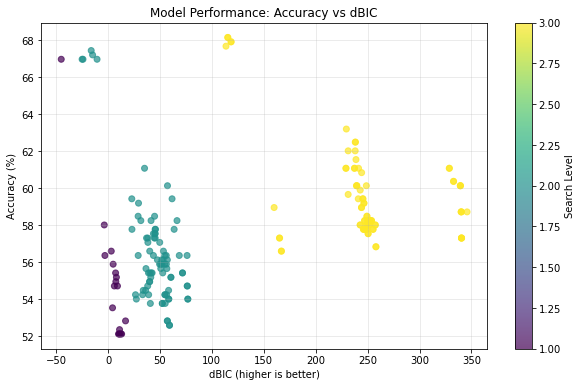


Detailed analysis of best model: IV:JKPZ
  Accuracy: 58.73%
  AIC: -90.67
  BIC: -345.80
  Alpha: 0.9982

Confusion Matrix:
  Sensitivity: 0.587
  Specificity: 0.587
  Precision: 0.587
  F1-Score: 0.587

Full Search Report:
  ID   MODEL                 ID          Model          Level              H            dDF            dLR          Alpha            Inf        %dH(DV)           dAIC           dBIC
 183   IV:ApJPZ                                                       9.6008             31                        0.0000                                     -11.9549       113.5868
 181   IV:ApBPZ                                                       9.6038             31                        0.0000                                     -10.2210       115.3207
 181   IV:ApBPZ                                                       9.6038             31                        0.0000                                     -10.2210       115.3207
 179   IV:ApNPZ                                

In [ ]:
# OCCAM High-Level API - Jupyter Notebook Example
# This shows how the new bindings provide a clean, simple interface

import pyoccam
import pandas as pd
import matplotlib.pyplot as plt

# ========== SIMPLE INITIALIZATION ==========

# One-line initialization
occam = pyoccam.OCCAM()
occam.init("dementia05.txt")

# Quick dataset overview
info = occam.get_dataset_info()
print(f"Dataset: {info['data_file']}")
print(f"Variables: {', '.join(info['variables'])}")
print(f"Sample size: {info['sample_size']}")
print(f"Has test data: {info['has_test_data']}")

# ========== SIMPLE PARAMETER ADJUSTMENT ==========

# Easy search with reasonable defaults
results = occam.search(
    algorithm="loopless",    # Clean algorithm names
    levels=3,                # Reasonable default
    width=5,                 # Keep top 5 at each level
    reference="bottom"       # Reference model
)

print(f"\nSearch completed in {results.elapsed_time:.2f} seconds")
print(f"Found {len(results.models)} models")

# ========== IMMEDIATE ACCESS TO BEST MODELS ==========

print(f"\nBest Models:")
print(f"  By BIC: {results.best_bic.name} (dBIC: {results.best_bic.dbic:.2f})")
print(f"  By AIC: {results.best_aic.name} (dAIC: {results.best_aic.daic:.2f})")
print(f"  By Information: {results.best_information.name} (H: {results.best_information.information:.4f})")

# ========== EASY DATA ANALYSIS ==========

# Convert to pandas DataFrame for analysis
df = pd.DataFrame([{
    'model': m.name,
    'level': m.level,
    'bic': m.bic,
    'aic': m.aic,
    'dbic': m.dbic,
    'daic': m.daic,
    'accuracy': m.pct_correct
} for m in results.models])

print(f"\nTop 5 models by dBIC:")
print(df.nlargest(5, 'dbic')[['model', 'level', 'dbic', 'accuracy']])

# ========== SIMPLE VISUALIZATION ==========

# Plot model performance
plt.figure(figsize=(10, 6))
plt.scatter(df['dbic'], df['accuracy'], c=df['level'], cmap='viridis', alpha=0.7)
plt.xlabel('dBIC (higher is better)')
plt.ylabel('Accuracy (%)')
plt.title('Model Performance: Accuracy vs dBIC')
plt.colorbar(label='Search Level')
plt.grid(True, alpha=0.3)
plt.show()

# ========== DETAILED MODEL ANALYSIS ==========

# Fit the best model for detailed analysis
best_model = results.best_bic.name
model_info = occam.fit(best_model)

print(f"\nDetailed analysis of best model: {best_model}")
print(f"  Accuracy: {model_info.pct_correct:.2f}%")
print(f"  AIC: {model_info.aic:.2f}")
print(f"  BIC: {model_info.bic:.2f}")
print(f"  Alpha: {model_info.alpha:.4f}")

# Get confusion matrix for classification
cm = occam.get_confusion_matrix(best_model, target_state="0")
print(f"\nConfusion Matrix:")
print(f"  Sensitivity: {cm['sensitivity']:.3f}")
print(f"  Specificity: {cm['specificity']:.3f}")
print(f"  Precision: {cm['precision']:.3f}")
print(f"  F1-Score: {cm['f1_score']:.3f}")

# ========== COMPREHENSIVE REPORTING ==========

# Get full search report (matches server output)
print("\nFull Search Report:")
print(results.search_report)

# Get detailed fit report
fit_report = occam.get_fit_report(best_model)
print(f"\nDetailed Fit Report for {best_model}:")
print(fit_report)

# ========== QUICK ONE-LINER FOR SIMPLE CASES ==========

# For quick analysis, use the convenience function
quick_results = pyoccam.quick_search("dementia05.txt", algorithm="loopless", levels=2)
print(f"\nQuick search found best model: {quick_results.best_bic.name}")

# ========== PERFORMANCE AWARENESS ==========

print(f"\nPerformance Guidelines:")
for level, desc in pyoccam.PERFORMANCE_GUIDE.items():
    print(f"  {level}: {desc}")

print(f"\nValid algorithms: {', '.join(pyoccam.VALID_ALGORITHMS)}")

# ========== ERROR HANDLING ==========

try:
    # This will fail gracefully
    bad_results = occam.search(algorithm="invalid_algorithm")
except RuntimeError as e:
    print(f"Caught expected error: {e}")

# ========== EXPORT RESULTS ==========

# Easy export to CSV for further analysis
results_dict = results.to_dict()
results_df = pd.DataFrame(results_dict['models'])
results_df.to_csv('occam_search_results.csv', index=False)
print("\nResults exported to occam_search_results.csv")

# ========== COMPARATIVE ANALYSIS ==========

# Compare different algorithms easily
algorithms = ["loopless", "full"]
comparison = {}

for alg in algorithms:
    comp_results = occam.search(algorithm=alg, levels=2, width=3)
    comparison[alg] = {
        'best_model': comp_results.best_bic.name,
        'best_dbic': comp_results.best_bic.dbic,
        'model_count': len(comp_results.models),
        'time': comp_results.elapsed_time
    }

comp_df = pd.DataFrame(comparison).T
print(f"\nAlgorithm Comparison:")
print(comp_df)